In [44]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons
from lamberthub import gooding1990


AU_KM = 149_597_870.7
DAY_S = 86_400.0

MU_SUN = 2.959122082855911e-4 # AU^3 / day^2


@dataclass(frozen=True)
class StateVector:
    r: np.ndarray  # position [AU], shape=(3,)
    v: np.ndarray  # velocity [AU/day], shape=(3,)


@dataclass(frozen=True)
class TransferResult:
    v_dep: np.ndarray  # heliocentric departure velocity [AU/day]
    v_arr: np.ndarray  # heliocentric arrival velocity [AU/day]
    vinf_dep: float    # Earth-relative departure v-infinity [km/s]
    vinf_arr: float    # AA29-relative arrival v-infinity [km/s]
    c3: float          # Earth departure C3 [km^2/s^2]
    tof_days: float    # flight time [day]

In [8]:
col = ['time', 'x', 'y', 'z', 'vx', 'vy', 'vz']

earth_vec = pd.read_csv('EARTH.aei', sep=r'\s+', skiprows=4, names=col)
aa29_vec = pd.read_csv('2002AA29.aei', sep=r'\s+', skiprows=4, names=col)

In [9]:
def au_per_day_to_km_per_s(value):
    return np.asarray(value) * AU_KM / DAY_S

def state_from_table(table, index):
    row = table.iloc[index]

    return StateVector(
        r=row[["x", "y", "z"]].to_numpy(dtype=float),
        v=row[["vx", "vy", "vz"]].to_numpy(dtype=float),
    )

def solve_lambert(
    earth_dep: StateVector,
    target_arr: StateVector,
    dep_jd: float,
    arr_jd: float,
    *,
    mu: float = MU_SUN,
) -> TransferResult:
    tof_days = float(arr_jd - dep_jd)

    v_sc_departure, v_sc_arrival = gooding1990(
        mu,
        earth_dep.r,
        target_arr.r,
        tof_days,
        M=0,
        prograde=True,
        low_path=True,
    )

    vinf_dep_au_day = np.linalg.norm(v_sc_departure - earth_dep.v)
    vinf_arr_au_day = np.linalg.norm(v_sc_arrival - target_arr.v)

    vinf_dep_km_s = float(au_per_day_to_km_per_s(vinf_dep_au_day))
    vinf_arr_km_s = float(au_per_day_to_km_per_s(vinf_arr_au_day))

    return TransferResult(
        v_dep=v_sc_departure,
        v_arr=v_sc_arrival,
        vinf_dep=vinf_dep_km_s,
        vinf_arr=vinf_arr_km_s,
        c3=vinf_dep_km_s**2,
        tof_days=tof_days,
    )

In [10]:
DEP_START_INDEX = 27 * 365
DEP_STOP_INDEX = 37 * 365

TOF_MIN_DAYS = 30
TOF_MAX_DAYS = 730

DATE_STEP_DAYS = 5
TOF_STEP_DAYS = 5

results = []

for dep_index in range(
    DEP_START_INDEX,
    DEP_STOP_INDEX + 1,
    DATE_STEP_DAYS,
):
    for tof_days in range(
        TOF_MIN_DAYS,
        TOF_MAX_DAYS + 1,
        TOF_STEP_DAYS,
    ):
        arr_index = dep_index + tof_days

        if arr_index >= len(aa29_vec):
            continue

        try:
            result = solve_lambert(
                state_from_table(earth_vec, dep_index),
                state_from_table(aa29_vec, arr_index),
                earth_vec["time"][dep_index],
                aa29_vec["time"][arr_index],
            )
        except ValueError:
            continue

        results.append({
            "dep_jd": earth_vec["time"][dep_index],
            "arr_jd": aa29_vec["time"][arr_index],
            "tof_days": result.tof_days,
            "c3_km2_s2": result.c3,
            "vinf_dep_km_s": result.vinf_dep,
            "vinf_arr_km_s": result.vinf_arr,
            "revolutions": 0,
        })

results_df = pd.DataFrame(results)

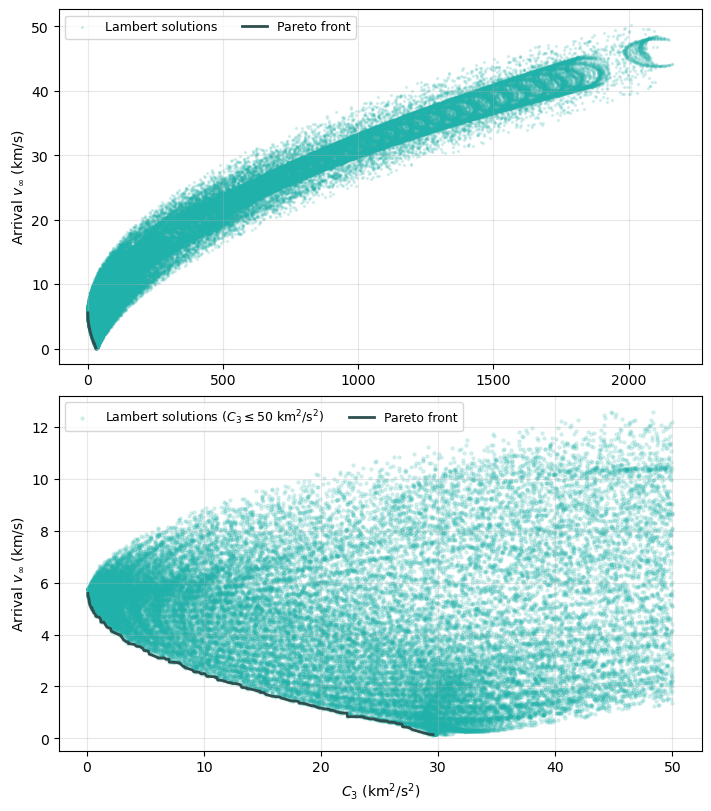

In [64]:
def get_pareto_front(df):
    df = df.sort_values("c3_km2_s2")

    best_vinf_arr = np.inf
    pareto_indices = []

    for index, row in df.iterrows():
        if row["vinf_arr_km_s"] < best_vinf_arr:
            pareto_indices.append(index)
            best_vinf_arr = row["vinf_arr_km_s"]

    return df.loc[pareto_indices]


pareto_df = get_pareto_front(results_df)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), constrained_layout=True)

ax1.scatter(
    results_df["c3_km2_s2"],
    results_df["vinf_arr_km_s"],
    s=2,
    color="lightseagreen",
    alpha=0.15,
    label="Lambert solutions",
)

ax1.plot(
    pareto_df["c3_km2_s2"],
    pareto_df["vinf_arr_km_s"],
    color="darkslategray",
    linewidth=2,
    label="Pareto front",
)

ax1.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax1.legend(ncol=2, fontsize=9)
ax1.grid(alpha=0.3)

low_c3 = results_df.query("c3_km2_s2 <= 50")
low_c3_2100 = results_df.query("c3_km2_s2 <= 50")

ax2.scatter(
    low_c3["c3_km2_s2"],
    low_c3["vinf_arr_km_s"],
    s=5,
    color="lightseagreen",
    alpha=0.15,
    label=r"Lambert solutions ($C_3 \leq 50$ km$^2$/s$^2$)",
)

ax2.plot(
    pareto_df["c3_km2_s2"],
    pareto_df["vinf_arr_km_s"],
    color="darkslategray",
    linewidth=2,
    label="Pareto front",
)

ax2.set_xlabel(r"$C_3$ (km$^2$/s$^2$)")
ax2.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax2.legend(ncol=2, fontsize=9)
ax2.grid(alpha=0.3)

fig.savefig(
    "v_c3_quasi_satellite.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.06,
)

plt.show()

In [12]:
#2100

def state_from_horizons(table, index):
    return StateVector(
        r=np.array(
            [table["x"][index], table["y"][index], table["z"][index]],
            dtype=float,
        ),
        v=np.array(
            [table["vx"][index], table["vy"][index], table["vz"][index]],
            dtype=float,
        ),
    )

epochs = {
    "start": "2090-01-01",
    "stop": "2110-01-01",
    "step": "1d",
}

earth_hor = Horizons(
    id="399",             # Earth center
    location="@sun",
    epochs=epochs,
)
earth_vec_2100 = earth_hor.vectors(refplane="ecliptic")

aa29_hor = Horizons(
    id="2002 AA29",
    id_type="smallbody",
    location="@sun",
    epochs=epochs,
)
aa29_vec_2100 = aa29_hor.vectors(refplane="ecliptic")

DEP_START_INDEX = 0
DEP_STOP_INDEX = 9 * 365 # 2027-01-01 ~ 2035

TOF_MIN_DAYS = 30
TOF_MAX_DAYS = 730

DATE_STEP_DAYS = 5
TOF_STEP_DAYS = 5

results_2100 = []

for dep_index in range(
    DEP_START_INDEX,
    DEP_STOP_INDEX + 1,
    DATE_STEP_DAYS,
):
    for tof_days in range(
        TOF_MIN_DAYS,
        TOF_MAX_DAYS + 1,
        TOF_STEP_DAYS,
    ):
        arr_index = dep_index + tof_days

        if arr_index >= len(aa29_vec_2100):
            continue

        try:
            result = solve_lambert(
                state_from_horizons(earth_vec_2100, dep_index),
                state_from_horizons(aa29_vec_2100, arr_index),
                earth_vec_2100["datetime_jd"][dep_index],
                aa29_vec_2100["datetime_jd"][arr_index],
            )
        except ValueError:
            continue

        results_2100.append({
            "dep_jd": earth_vec_2100["datetime_jd"][dep_index],
            "arr_jd": aa29_vec_2100["datetime_jd"][arr_index],
            "tof_days": result.tof_days,
            "c3_km2_s2": result.c3,
            "vinf_dep_km_s": result.vinf_dep,
            "vinf_arr_km_s": result.vinf_arr,
            "revolutions": 0,
        })

results_df_2100 = pd.DataFrame(results_2100)
pareto_df_2100 = get_pareto_front(results_df_2100)

def front_curve(df):
    return (
        df.sort_values("c3_km2_s2")
        .groupby("c3_km2_s2", as_index=False)["vinf_arr_km_s"]
        .min()
    )

front_2100 = front_curve(pareto_df_2100)
front_qs = front_curve(pareto_df)

c_min = max(
    front_2100["c3_km2_s2"].min(),
    front_qs["c3_km2_s2"].min(),
)
c_max = min(
    20.0,
    front_2100["c3_km2_s2"].max(),
    front_qs["c3_km2_s2"].max(),
)

c_grid = np.linspace(c_min, c_max, 500)

v_2100 = np.interp(
    c_grid,
    front_2100["c3_km2_s2"],
    front_2100["vinf_arr_km_s"],
)

v_qs = np.interp(
    c_grid,
    front_qs["c3_km2_s2"],
    front_qs["vinf_arr_km_s"],
)

delta_vinf = v_qs - v_2100

print("평균 Δv∞ [km/s]:", delta_vinf.mean())
print("최대 |Δv∞| [km/s]:", np.abs(delta_vinf).max())
print("RMSE [km/s]:", np.sqrt(np.mean(delta_vinf**2)))

평균 Δv∞ [km/s]: 0.019793296549820334
최대 |Δv∞| [km/s]: 0.20466144685191345
RMSE [km/s]: 0.05763951194076143


minimum c3: 0.1004679850761456
minimum vinf_arr: 0.14712050552575995


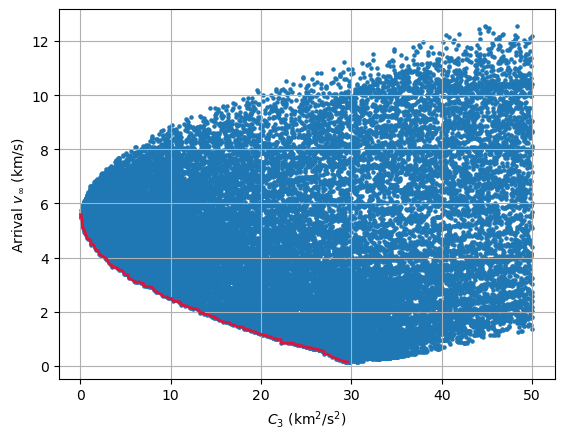

In [ ]:
low_c3 = results_df.query("c3_km2_s2 <= 50")
low_c3_2100 = results_df.query("c3_km2_s2 <= 50")

plt.scatter(
    low_c3["c3_km2_s2"],
    low_c3["vinf_arr_km_s"],
    s=5,
)

plt.plot(
    pareto_df["c3_km2_s2"],
    pareto_df["vinf_arr_km_s"],
    color="crimson",
    linewidth=2,
    label="Pareto front",
)
plt.xlabel(r"$C_3$ ($\mathrm{km}^2/\mathrm{s}^2$)")
plt.ylabel(r"Arrival $v_\infty$ (km/s)")
plt.grid()
plt.show()

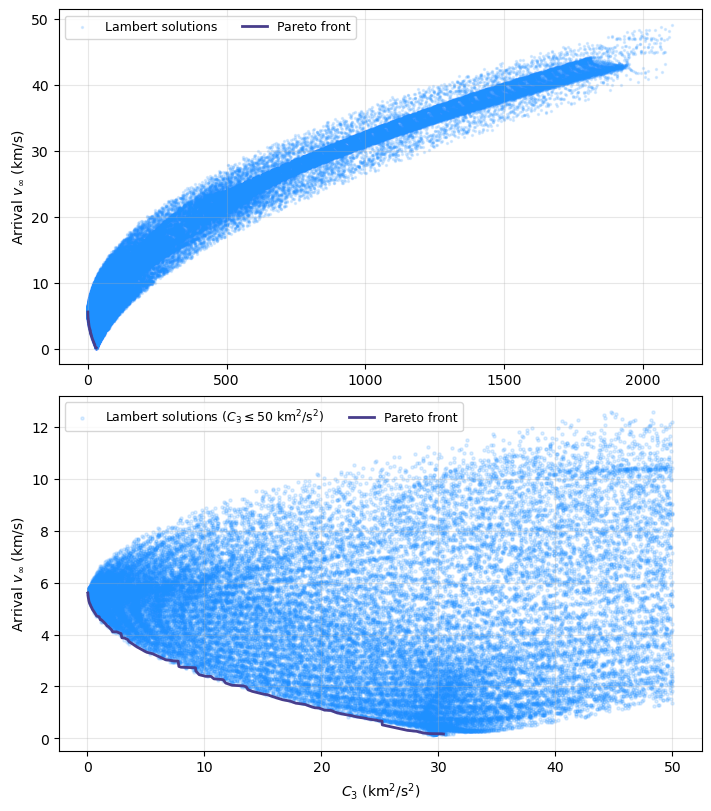

In [65]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), constrained_layout=True)

ax1.scatter(
    results_df_2100["c3_km2_s2"],
    results_df_2100["vinf_arr_km_s"],
    s=2,
    color="dodgerblue",
    alpha=0.15,
    label="Lambert solutions",
)

ax1.plot(
    pareto_df_2100["c3_km2_s2"],
    pareto_df_2100["vinf_arr_km_s"],
    color="darkslateblue",
    linewidth=2,
    label="Pareto front",
)

ax1.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax1.legend(ncol=2, fontsize=9)
ax1.grid(alpha=0.3)

ax2.scatter(
    low_c3_2100["c3_km2_s2"],
    low_c3_2100["vinf_arr_km_s"],
    s=5,
    color="dodgerblue",
    alpha=0.15,
    label=r"Lambert solutions ($C_3 \leq 50$ km$^2$/s$^2$)",
)

ax2.plot(
    pareto_df_2100["c3_km2_s2"],
    pareto_df_2100["vinf_arr_km_s"],
    color="darkslateblue",
    linewidth=2,
    label="Pareto front",
)

ax2.set_xlabel(r"$C_3$ (km$^2$/s$^2$)")
ax2.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax2.legend(ncol=2, fontsize=9)
ax2.grid(alpha=0.3)

fig.savefig(
    "v_c3_2100.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.06,
)

plt.show()

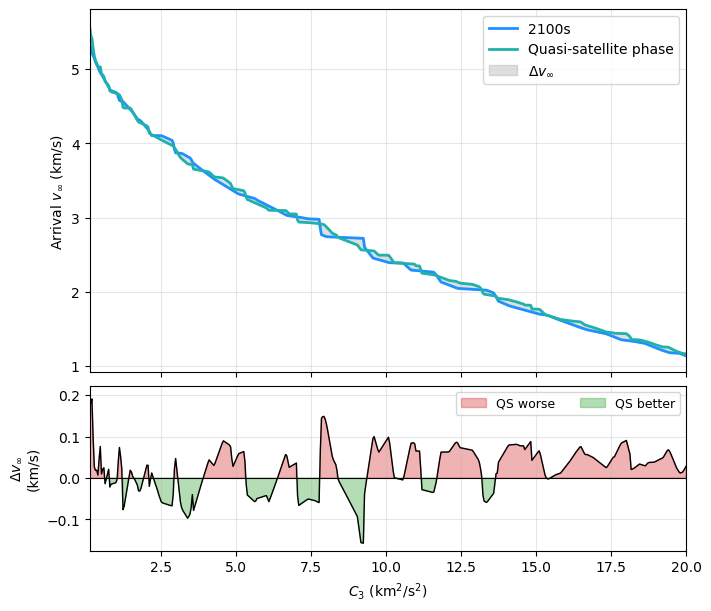

In [66]:
plt.rcdefaults()
fig, (ax0, ax1) = plt.subplots(
    2, 1,
    figsize=(7, 6),
    sharex=True,
    height_ratios=[2.2, 1],
    constrained_layout=True,
)

# 위: 두 Pareto front와 그 차이
ax0.plot(c_grid, v_2100, color="dodgerblue", lw=2, label="2100s")
ax0.plot(c_grid, v_qs, color="lightseagreen", lw=2, label="Quasi-satellite phase")

ax0.fill_between(
    c_grid,
    v_2100,
    v_qs,
    color="gray",
    alpha=0.25,
    label=r"$\Delta v_\infty$",
)

ax0.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax0.set_xlim(c_grid.min(), c_grid.max())
ax0.legend()
ax0.grid(alpha=0.3)

# 아래: signed difference
ax1.axhline(0, color="black", lw=0.8)

ax1.fill_between(
    c_grid, 0, delta_vinf,
    where=delta_vinf >= 0,
    color="tab:red",
    alpha=0.35,
    label="QS worse",
)

ax1.fill_between(
    c_grid, 0, delta_vinf,
    where=delta_vinf < 0,
    color="tab:green",
    alpha=0.35,
    label="QS better",
)

ax1.plot(c_grid, delta_vinf, color="black", lw=1)

ax1.set_xlabel(r"$C_3$ (km$^2$/s$^2$)")
ax1.set_ylabel(r"$\Delta v_\infty$" "\n(km/s)")
ax1.legend(ncol=2, fontsize=9)
ax1.grid(alpha=0.3)

fig.savefig(
    "pareto_front_comparison.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.06,
)

plt.show()

In [14]:
front_10_20 = pareto_df[
    pareto_df["c3_km2_s2"].between(10, 20)
].copy()

print(
    front_10_20[
        [
            "dep_jd",
            "arr_jd",
            "tof_days",
            "c3_km2_s2",
            "vinf_dep_km_s",
            "vinf_arr_km_s",
        ]
    ].sort_values("c3_km2_s2")
)

              dep_jd        arr_jd  tof_days  c3_km2_s2  vinf_dep_km_s  \
33      2.672512e+06  2.672707e+06     195.0  10.081061       3.175069   
82655   2.675442e+06  2.675617e+06     175.0  10.256234       3.202536   
51498   2.674337e+06  2.674532e+06     195.0  10.941395       3.307778   
20896   2.673252e+06  2.673422e+06     170.0  10.977772       3.313272   
77302   2.675252e+06  2.675452e+06     200.0  11.120740       3.334777   
5562    2.672707e+06  2.673052e+06     345.0  11.177491       3.343275   
67286   2.674897e+06  2.675072e+06     175.0  11.606460       3.406826   
61930   2.674707e+06  2.674892e+06     185.0  12.091581       3.477295   
10603   2.672887e+06  2.673057e+06     170.0  12.324379       3.510609   
67009   2.674887e+06  2.675087e+06     200.0  12.451935       3.528730   
5700    2.672712e+06  2.673042e+06     330.0  12.871786       3.587727   
82793   2.675447e+06  2.675607e+06     160.0  13.089034       3.617877   
102965  2.676162e+06  2.676367e+06    

In [15]:
for c3_target in [10, 15, 20]:
    candidate = pareto_df.loc[
        (pareto_df["c3_km2_s2"] - c3_target).abs().idxmin()
    ]

    print(
        f"\nC3 ≈ {c3_target}"
        f"\nDeparture JD : {candidate['dep_jd']}"
        f"\nArrival JD   : {candidate['arr_jd']}"
        f"\nTOF          : {candidate['tof_days']:.0f} days"
        f"\nC3           : {candidate['c3_km2_s2']:.3f} km²/s²"
        f"\nArrival v∞   : {candidate['vinf_arr_km_s']:.3f} km/s"
    )


C3 ≈ 10
Departure JD : 2672511.5002
Arrival JD   : 2672706.5002
TOF          : 195 days
C3           : 10.081 km²/s²
Arrival v∞   : 2.493 km/s

C3 ≈ 15
Departure JD : 2672881.5002
Arrival JD   : 2673066.5002
TOF          : 185 days
C3           : 15.108 km²/s²
Arrival v∞   : 1.766 km/s

C3 ≈ 20
Departure JD : 2675261.5002
Arrival JD   : 2675426.5002
TOF          : 165 days
C3           : 19.889 km²/s²
Arrival v∞   : 1.169 km/s


In [16]:
dep_center = 2672881.5002
arr_center = 2673066.5002

refined_results = []

for dep_jd in np.arange(dep_center - 20, dep_center + 21, 1):
    for arr_jd in np.arange(arr_center - 20, arr_center + 21, 1):
        if arr_jd <= dep_jd:
            continue

        dep_index = np.argmin(
            np.abs(earth_vec["time"] - dep_jd)
        )
        arr_index = np.argmin(
            np.abs(aa29_vec["time"] - arr_jd)
        )

        result = solve_lambert(
            state_from_table(earth_vec, dep_index),
            state_from_table(aa29_vec, arr_index),
            earth_vec["time"][dep_index],
            aa29_vec["time"][arr_index],
        )

        refined_results.append({
            "dep_jd": earth_vec["time"][dep_index],
            "arr_jd": aa29_vec["time"][arr_index],
            "tof_days": result.tof_days,
            "c3_km2_s2": result.c3,
            "vinf_arr_km_s": result.vinf_arr,
        })

refined_df = pd.DataFrame(refined_results)

reference = refined_df.query(
    "c3_km2_s2 <= 20"
).nsmallest(
    1,
    "vinf_arr_km_s",
)

print(reference)

           dep_jd        arr_jd  tof_days  c3_km2_s2  vinf_arr_km_s
807  2.672881e+06  2.673075e+06     194.0  19.928983        1.23361


In [17]:
candidate = refined_df.loc[989]

dep_jd = candidate["dep_jd"]
arr_jd = candidate["arr_jd"]

dep_index = np.argmin(
    np.abs(earth_vec["time"] - dep_jd)
)

arr_index = np.argmin(
    np.abs(aa29_vec["time"] - arr_jd)
)

earth_dep = state_from_table(
    earth_vec,
    dep_index,
)

aa29_arr = state_from_table(
    aa29_vec,
    arr_index,
)

result = solve_lambert(
    earth_dep,
    aa29_arr,
    dep_jd,
    arr_jd,
)

r_dep = earth_dep.r       # 지구의 태양 중심 출발 위치 [AU]
v_earth = earth_dep.v     # 지구의 태양 중심 출발 속도 [AU/day]

v_sc_dep = result.v_dep   # 탐사선의 태양 중심 출발 속도 [AU/day]
v_sc_arr = result.v_arr   # 탐사선의 태양 중심 도착 속도 [AU/day]

In [18]:
from scipy.integrate import solve_ivp


def propagate_sun_2body(r0, v0, dt_days, mu=MU_SUN):
    """AU, AU/day 단위의 태양 2체 전파."""
    y0 = np.hstack((r0, v0))

    def rhs(_, y):
        r = y[:3]
        v = y[3:]
        a = -mu * r / np.linalg.norm(r)**3

        return np.hstack((v, a))

    solution = solve_ivp(
        rhs,
        (0.0, dt_days),
        y0,
        rtol=1e-12,
        atol=1e-14,
    )

    return solution.y[:3, -1], solution.y[3:, -1]

r_sc_start, v_sc_start = propagate_sun_2body(
    r0=r_dep,
    v0=v_sc_dep,
    dt_days=15.0,
)

print(r_sc_start)
print(v_sc_start)

[-0.34267454  0.91418153  0.03988901]
[-0.01611506 -0.00657989  0.00268546]


In [19]:

print(earth_vec["time"].iloc[[0, -1]])
print(aa29_vec["time"].iloc[[0, -1]])

print(np.linalg.norm(
    aa29_vec[["x", "y", "z"]].to_numpy()
    - earth_vec[["x", "y", "z"]].to_numpy(),
    axis=1
).min())

0        2.662657e+06
16069    2.678726e+06
Name: time, dtype: float64
0        2.662657e+06
16069    2.678726e+06
Name: time, dtype: float64
0.03186840252811617
